# 2. Data Understanding

In this phase we describe **where the data comes from**, **what a Minecraft skin actually is** as
a data object, and **what the dataset looks like statistically** before any preparation step.

---

## 2.1 What is a Minecraft skin?

A Minecraft skin is a fixed-size **64 × 64 RGBA PNG image**. JPEG is not used because the format
relies on a transparent alpha channel for second-layer geometry (hats, jackets, sleeves).

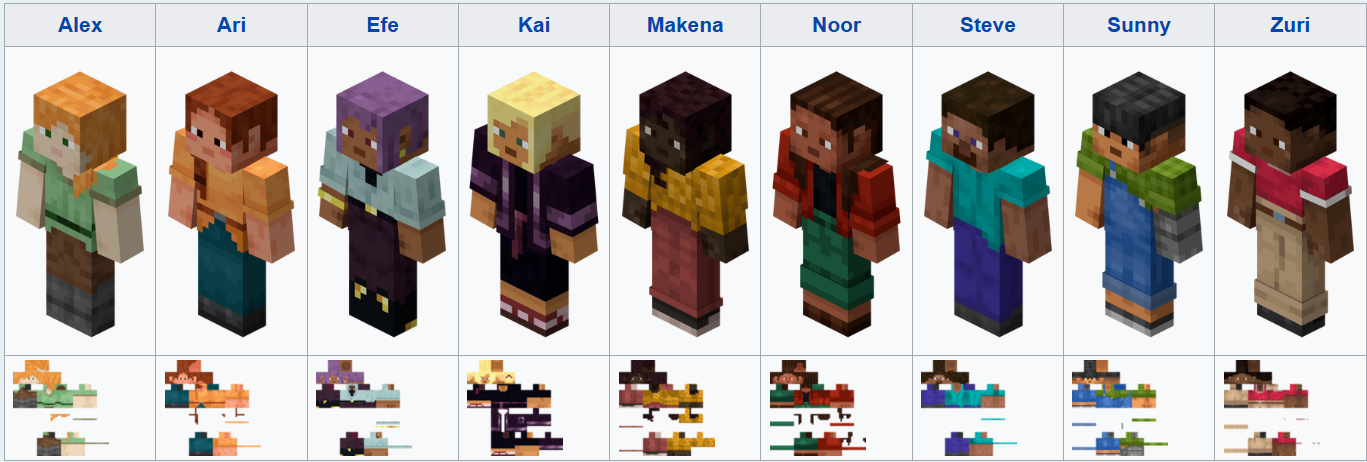

The image is not a flat picture of a character — it is a **UV-unwrapped texture atlas**. Specific
rectangular regions of the 64×64 image map onto specific faces of the character model. e.g. Head, legs, second layer

Official format reference: https://minecraft.wiki/w/Skin

**Why this matters for ML:**

- Spatial positions of features are **fixed by the format**, we assume its not random, eventhough there is no check
  head region is always the head region.
- This means **rotations, flips, crops, and translations are *not* valid data augmentations** —
  they would scramble the UV layout. Color-based augmentation (jitter, noise) is the only safe
  family.
- The **alpha channel is informational**, not cosmetic. It functions as a mask telling the model
  which pixels belong to the skin's second layer ("hat") and which are blank. Discarding it
  destroys signal. We keep all 4 channels (RGBA).

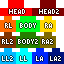
---

## 2.2 Data sources

We use two completely separate data sources for the two classes:

### Class 0 — "Normal" skins (the negative / majority class)

**Source:** A Kaggle dataset of 600,000+ unlabeled Minecraft skins:
https://www.kaggle.com/datasets/sha2048/minecraft-skin-dataset

The dataset author generated player names programmatically and downloaded their skins
through the official Mojang API. From the dataset description:

> "I made this dataset by generating a list of player names and then downloading the skins from the
> Minecraft API."

This means our "normal" class is a representative sample of **skins actually worn by real
Minecraft players** — not synthetic or curated images. So there can already be flagged skins
(Spider-Man, military, etc.) in this distribution.

We took the first 9,000 images for `data/skins/good/`.

#### A note on our earlier attempt

Our first plan was to harvest skins ourselves by resolving UUIDs from
https://matdoes.dev/minecraft-uuids (a public list of ~51 million Minecraft UUIDs) against
the Mojang skin API. This is implemented in
`02_DataUnderstanding/Mining/SkinsFromUuid/minecraft_skin_downloader.py`

We abandoned this approach for the dataset because **Mojang aggressively rate-limits its skin
API**, making bulk download impractical for 10k+ skins. The Kaggle dataset is effectively a
pre-scraped version of the same data. The UUID-based downloader code is retained because
the **deployment service** still needs to fetch a single skin on demand at player-join time —
where the rate limit is irrelevant.

### Class 1 — "Spider-Man" skins (the positive / minority class)

**Source:** Custom keyword scraper against `minecraftskins.com`, code at
`02_DataUnderstanding/Mining/SkinsByKeyword/minecraft_keyword_scraper.py`.

Notable implementation details:

- `minecraftskins.com` is behind **Cloudflare**, so we use `cloudscraper` rather than `requests`.
- Skin IDs are parsed from `/skin/<id>/...` URLs on the search-results page.
- PNGs are downloaded via the direct endpoint `/skin/download/<id>`.
- The scraper paginates, handles delays and errors, and stops once
  `target_count` images have been collected.
- Output: `data/skins/bad/<keyword>/<keyword>_<id>.png`.

We collected 1,000 skins for the keyword `spiderman`. The same scraper was also run for
`bikini` and `ww2` as a demonstration that the pipeline generalizes (these classes are not
used in modeling).



In [8]:
from pathlib import Path
import sys

# robust project root detection for notebook runs from project root or 02_DataUnderstanding
cwd = Path.cwd().resolve()
if (cwd / "02_DataUnderstanding").exists():
    project_root = cwd
elif cwd.name == "02_DataUnderstanding":
    project_root = cwd.parent
else:
    project_root = cwd

scraper_dir = project_root / "02_DataUnderstanding" / "Mining" / "SkinsByKeyword"
if str(scraper_dir) not in sys.path:
    sys.path.append(str(scraper_dir))

from minecraft_keyword_scraper import run

KEYWORD = "spiderman"
TARGET_COUNT = 1000
OUTPUT_ROOT = project_root / "data" / "skins" / "bad"

RETRY_ATTEMPTS = 3
RETRY_SLEEP_SECONDS = 2.0
POLITENESS_SLEEP_RANGE = (1.0, 3.0)
TIMEOUT_SECONDS = 25
START_PAGE = 1
MAX_PAGES = 1000
OVERWRITE = False


In [9]:
downloaded_paths = run(
    keyword=KEYWORD,
    target_count=TARGET_COUNT,
    output_root=str(OUTPUT_ROOT),
    retry_attempts=RETRY_ATTEMPTS,
    retry_sleep_seconds=RETRY_SLEEP_SECONDS,
    politeness_sleep_range=POLITENESS_SLEEP_RANGE,
    timeout_seconds=TIMEOUT_SECONDS,
    start_page=START_PAGE,
    max_pages=MAX_PAGES,
    overwrite=OVERWRITE,
)

len(downloaded_paths), downloaded_paths[:5]

2026-04-06 17:04:28,583 | INFO | Keyword scrape start: keyword=spiderman target_count=1000
2026-04-06 17:04:29,173 | INFO | Page 1 yielded 58 skin IDs
2026-04-06 17:04:31,918 | INFO | Progress: 1/1000 | spiderman_14983961.png
2026-04-06 17:04:33,338 | INFO | Progress: 2/1000 | spiderman_15007020.png
2026-04-06 17:04:35,449 | INFO | Progress: 3/1000 | spiderman_16332784.png
2026-04-06 17:04:38,046 | INFO | Progress: 4/1000 | spiderman_15006547.png
2026-04-06 17:04:40,946 | INFO | Progress: 5/1000 | spiderman_22119922.png
2026-04-06 17:04:42,828 | INFO | Progress: 6/1000 | spiderman_15413019.png
2026-04-06 17:04:44,781 | INFO | Progress: 7/1000 | spiderman_15745048.png
2026-04-06 17:04:47,836 | INFO | Progress: 8/1000 | spiderman_18664861.png
2026-04-06 17:04:50,823 | INFO | Progress: 9/1000 | spiderman_21830911.png
2026-04-06 17:04:52,580 | INFO | Progress: 10/1000 | spiderman_20145819.png
2026-04-06 17:04:55,059 | INFO | Progress: 11/1000 | spiderman_22698649.png
2026-04-06 17:04:56,84

(1000,
 [WindowsPath('D:/FH/ml_project/data/skins/bad/spiderman/spiderman_14983961.png'),
  WindowsPath('D:/FH/ml_project/data/skins/bad/spiderman/spiderman_15007020.png'),
  WindowsPath('D:/FH/ml_project/data/skins/bad/spiderman/spiderman_16332784.png'),
  WindowsPath('D:/FH/ml_project/data/skins/bad/spiderman/spiderman_15006547.png'),
  WindowsPath('D:/FH/ml_project/data/skins/bad/spiderman/spiderman_22119922.png')])

---

## 2.3 Dataset size and class distribution

After collection (before cleaning):

| Folder | Class | Count | Notes |
|---|---|---|---|
| `data/skins/good/` | 0 (normal) | 9,000 | First slice of Kaggle dataset |
| `data/skins/bad/spiderman/` | 1 (Spider-Man) | 1,000 | Keyword scraper, page-paginated |
| `data/skins/bad/bikini/` | — | 1,000 | Not used in modeling |
| `data/skins/bad/ww2/` | — | 1,000 | Not used in modeling |

After manual cleaning (see Modeling and Data Preparation phase):

| Folder | Class | Count |
|---|---|---|
| `data/skins/good_cleaned/` | 0 (normal) | 9,041 |
| `data/skins/bad/spiderman_cleaned/` | 1 (Spider-Man) | 959 |
| **Total** | — | **10,000** |
| Imbalance ratio (1:0) | — | **~10.6 %** |

The class imbalance is significant but not extreme. It is handled in Modeling via class weights
and in Evaluation via threshold tuning

## 2.4 Small EDA

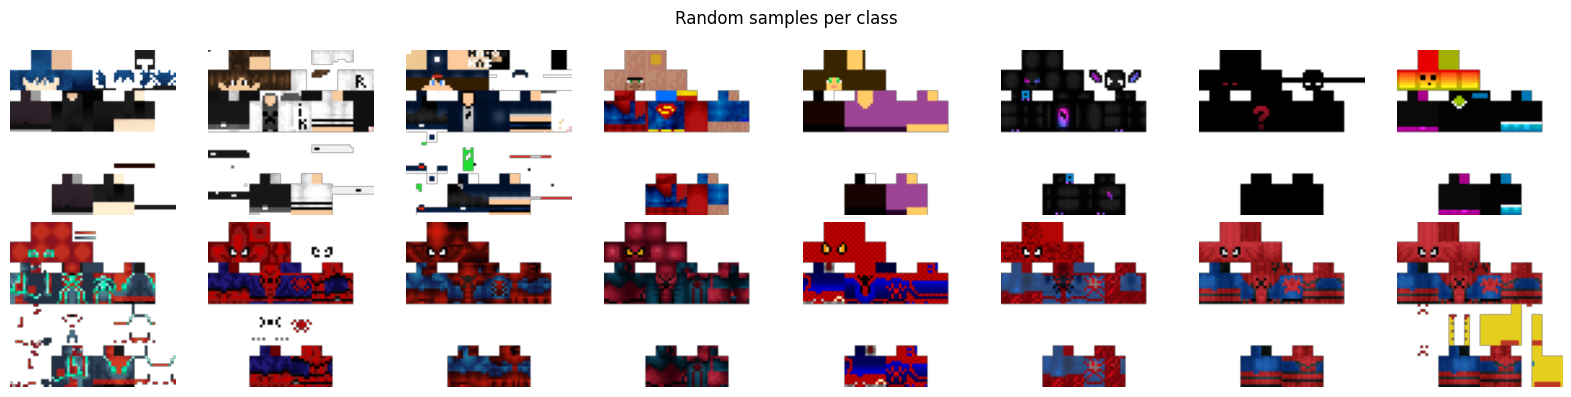

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

GOOD_DIR = Path("../data/skins/good_cleaned")
BAD_DIR  = Path("../data/skins/bad/spiderman_cleaned")

good_paths = sorted(GOOD_DIR.glob("*.png"))[:8]
bad_paths  = sorted(BAD_DIR.glob("*.png"))[:8]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for ax, p in zip(axes[0], good_paths):
    ax.imshow(Image.open(p)); ax.axis("off")
axes[0, 0].set_ylabel("normal", fontsize=12)

for ax, p in zip(axes[1], bad_paths):
    ax.imshow(Image.open(p)); ax.axis("off")
axes[1, 0].set_ylabel("spiderman", fontsize=12)

plt.suptitle("Random samples per class")
plt.tight_layout(); plt.show()

### Image-size sanity check
confirm every file is actually 64x64

In [3]:
from collections import Counter
sizes = Counter()
for p in list(GOOD_DIR.glob("*.png")) + list(BAD_DIR.glob("*.png")):
    img = Image.open(p)
    sizes[img.size] += 1
print("sizes:", sizes)

sizes: Counter({(64, 64): 10000})


In [4]:
# Mean image per class — gives a first hint about what the model can learn
def mean_image(folder):
    arrs = [np.asarray(Image.open(p).convert("RGBA")) / 255.0
            for p in folder.glob("*.png")]
    return np.mean(arrs, axis=0)


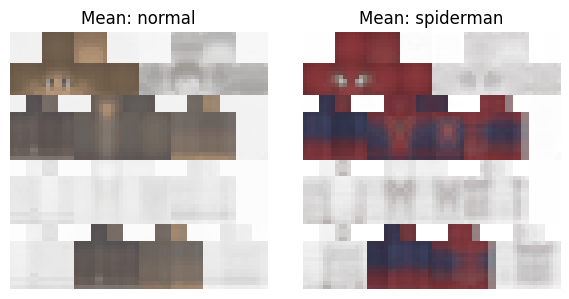

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(mean_image(GOOD_DIR)); ax[0].set_title("Mean: normal")
ax[1].imshow(mean_image(BAD_DIR));  ax[1].set_title("Mean: spiderman")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

The mean Spider-Man skin has a visibly red-and-blue color distribution. The classes are visually separable on color statistics alone but the spiderman dataset also has different colored versions

## 2.5 Label noise

The "good" class is *assumed good* It contains a random sample of player skins.
A small fraction of these are likely to be Spider-Man skins themselves (or visually similar, e.g. Deadpool).

This has two consequences:

1. The reported precision is a **lower bound**: when the model flags a "normal" skin as Spider-Man, the flag may actually be correct.
2. During manual cleaning, we observed exactly this behaviour: the trained CNN's strongest
   false positives on `good/` turned out to be real Spider-Man skins. This was a positive
   signal — the model was learning the right visual concept, not noise — and these cases were
   moved across folders before retraining (see Data Preparation).

## 2.6 3D skin view test
This is purely a experimental utility, not part of the training or deployment pipeline.

```powershell
python 02_DataUnderstanding/skin.py
```

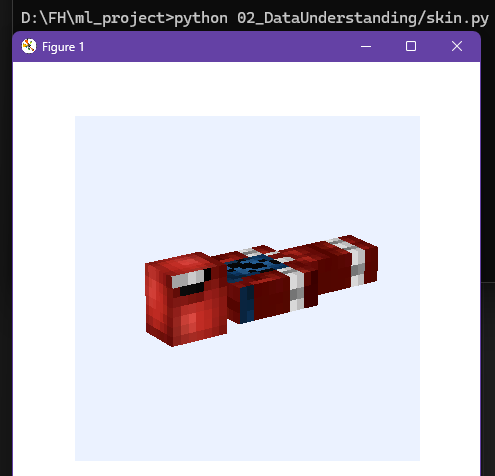

## 2.7 Summary

- Skins are 64×64, UV-unwrapped, with the alpha channel acting as a structural mask.
- Negative class (9k) comes from a Kaggle dataset of real Mojang-API-sourced player skins.
- Positive class (1k) is the Cloudflare-aware keyword scrape of `minecraftskins.com`.
- Imbalance is 9:1; manageable with class weights and threshold tuning.
- Label noise lives in the negative class and is *informative* — strong CNN false-positives.